# Integration and Plotting

This tutorial covers integrating orbits in potentials, plotting their
trajectories, accessing orbital quantities, and working with
non-inertial reference frames.

In [1]:
%matplotlib inline
import numpy
from astropy import units
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014, LogarithmicHaloPotential
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Basic integration

Use `o.integrate(ts, pot)` to integrate an orbit.

In [2]:
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 10.0, 10000)
o.integrate(ts, MWPotential2014)
print("Integration complete. Final R =", o.R(ts[-1]))

Integration complete. Final R = 1.0478229328266577


## Automatic time determination

You can pass just the potential and galpy will integrate for ~10 dynamical times.

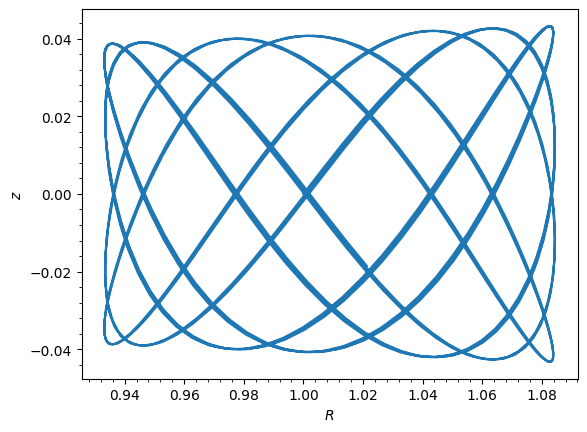

In [3]:
o_auto = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
o_auto.integrate(MWPotential2014)
o_auto.plot();

## Physical units for time

When using `ro=` and `vo=`, you can pass time arrays in physical units.

In [6]:
o_phys = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0], ro=8.0, vo=220.0)
ts_phys = numpy.linspace(0.0, 5.0, 1000) * units.Gyr
o_phys.integrate(ts_phys, MWPotential2014)
print("R at 5 Gyr =", o_phys.R(ts_phys[-1]))

R at 5 Gyr = 7.704903471220543


<div class="alert alert-warning">

**Warning**

When the integration times are not specified using a Quantity, they are assumed to be in natural units.

</div>

## Parallel integration of multiple orbits

Multi-orbit objects are integrated in parallel.

In [7]:
numpy.random.seed(42)
vxvvs = numpy.column_stack(
    [
        numpy.random.uniform(0.8, 1.2, 100),
        numpy.random.normal(0.0, 0.05, 100),
        numpy.random.uniform(0.9, 1.1, 100),
        numpy.random.normal(0.0, 0.05, 100),
        numpy.random.normal(0.0, 0.05, 100),
        numpy.random.uniform(0.0, 2 * numpy.pi, 100),
    ]
)
os = Orbit(vxvvs)
ts = numpy.linspace(0.0, 10.0, 1001)
os.integrate(ts, MWPotential2014)
print("All", os.size, "orbits integrated.")
print("R shape at all times:", os.R(ts).shape)

All 100 orbits integrated.
R shape at all times: (100, 1001)


## Continuing integrations

galpy supports *continuing* orbit integrations in both forward and backward time
directions. For forward continuation, if the first time of the new integration
matches the last time of the previous integration, the two are merged into a single
continuous orbit. Backward continuation works similarly: if the first time of the new
integration matches the first time of the previous one and goes in the opposite
direction, the orbit is integrated backward and prepended.

The two time arrays do not need the same number of points or spacing. The only
requirement is that the starting time of the new array matches the appropriate
endpoint of the existing one.

Time range now covers t = -5 to 10


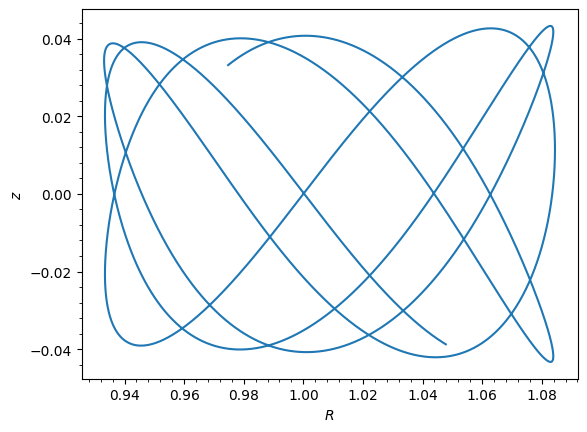

In [8]:
o_cont = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])

# Forward integration
ts_fwd = numpy.linspace(0.0, 5.0, 5000)
o_cont.integrate(ts_fwd, MWPotential2014)

# Continue forward
ts_ext = numpy.linspace(5.0, 10.0, 5000)
o_cont.integrate(ts_ext, MWPotential2014)

# Backward integration from t=0
ts_bwd = numpy.linspace(0.0, -5.0, 5000)
o_cont.integrate(ts_bwd, MWPotential2014)

print("Time range now covers t = -5 to 10")
o_cont.plot();

## Displaying orbits: various projections

Use `o.plot()` with `d1` and `d2` to select projections.

In [9]:
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 10.0, 10000)
o.integrate(ts, MWPotential2014)

The default projection is $R$ vs. $z$ (meridional plane):

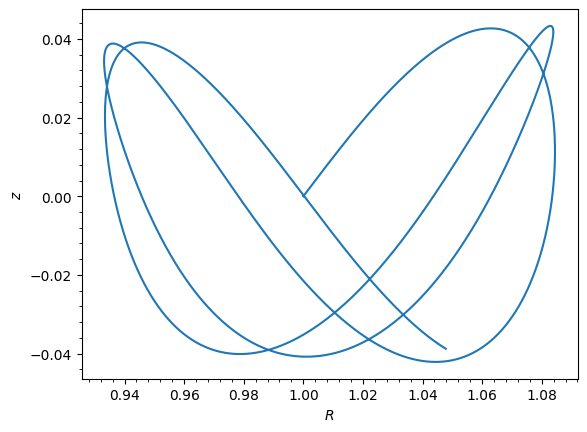

In [10]:
# Default: R vs. z (meridional plane)
o.plot();

Face-on view in the disk plane (`x` vs. `y`):

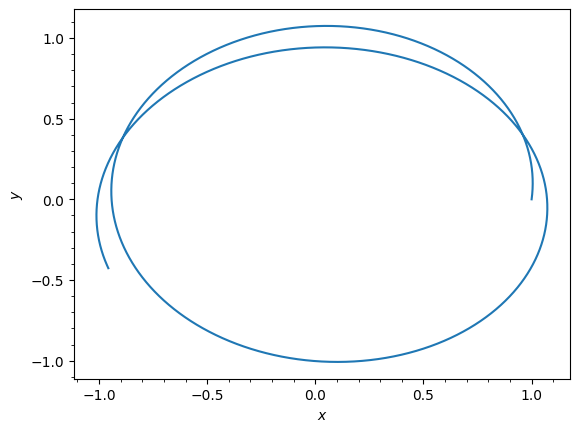

In [11]:
# Face-on view: x vs. y
o.plot(d1="x", d2="y");

Phase-space projections (`R` vs. `vR`):

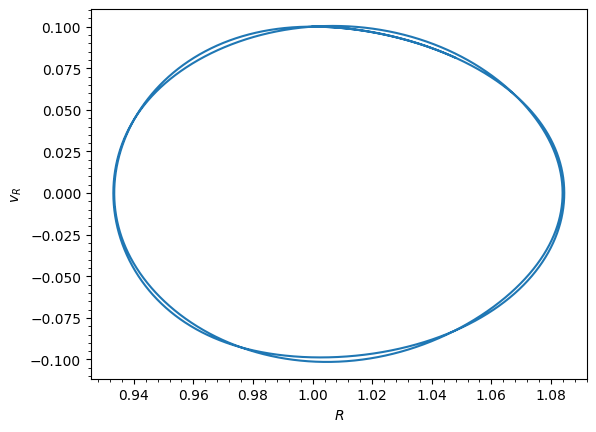

In [12]:
# Phase space: R vs. vR
o.plot(d1="R", d2="vR");

Sky coordinates can also be plotted when `ro` and `vo` are set. Here we plot Galactic `(l, b)`:

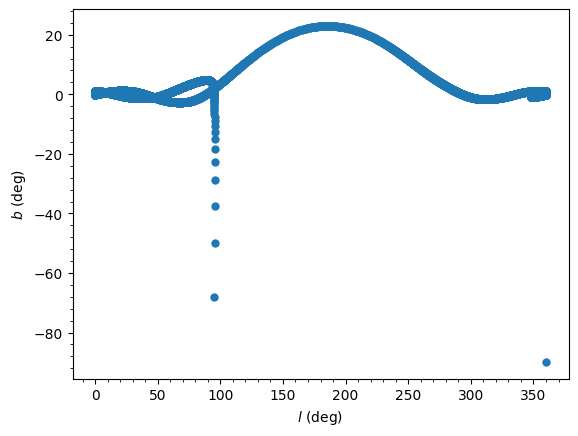

In [13]:
# Sky coordinates (requires ro/vo)
o_sky = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0], ro=8.0, vo=220.0)
o_sky.integrate(ts, MWPotential2014)
o_sky.plot(d1="ll", d2="bb", marker="o", ms=5, ls="None");

And equatorial `(RA, Dec)`:

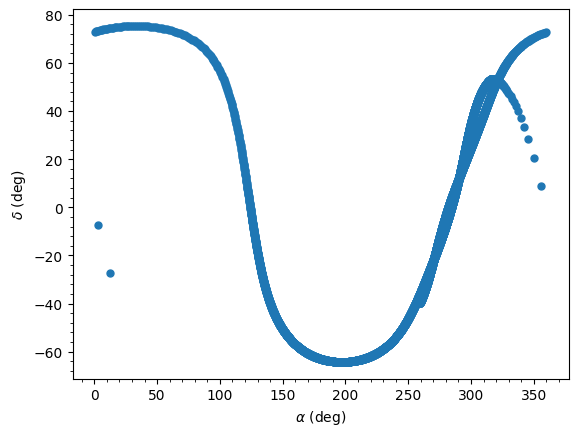

In [14]:
o_sky.plot(d1="ra", d2="dec", marker="o", ms=5, ls="None");

## Custom expression plotting

You can use arbitrary expressions in `o.plot()` calls using `numexpr` syntax (requires the `numexpr` package). For example, `o.plot(d1="t", d2="R*cos(phi)")` will evaluate the expression and plot it directly. If `numexpr` is not installed, you can install it with `pip install numexpr`.

Let's demonstrate both approaches:

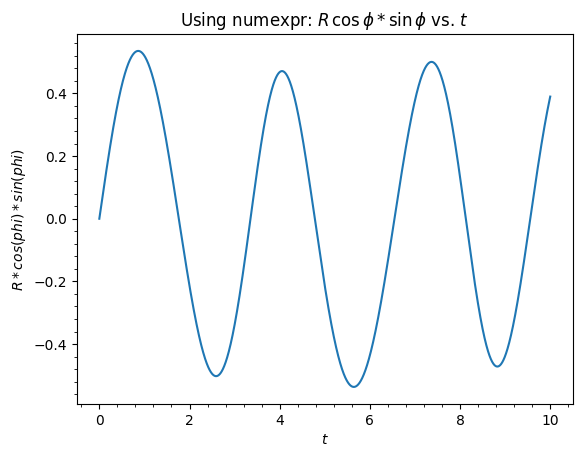

In [19]:
import numexpr
from matplotlib import pyplot as plt

# Using numexpr expressions directly in o.plot()
o.plot(d1="t", d2="R*cos(phi)*sin(phi)")
plt.title(r"Using numexpr: $R\,\cos\phi*\sin\phi$ vs. $t$");

Without `numexpr`, you can specify the computation manually using a lambda function of time given as ``d1`` or ``d2``, which is useful for functions that cannot be parsed by ``numexpr``.

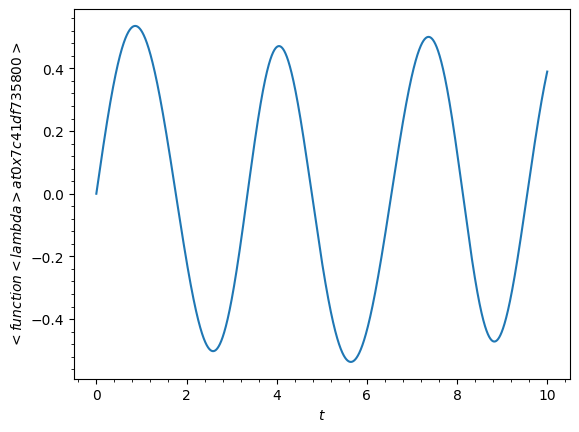

In [23]:
o.plot(d1="t", d2=lambda t: o.R(t) * numpy.cos(o.phi(t)) * numpy.sin(o.phi(t)));

## Orbit characterization

After integration, compute orbital parameters numerically.

In [24]:
print("Eccentricity:", o.e())
print("Apocenter:", o.rap())
print("Pericenter:", o.rperi())
print("Max |z|:", o.zmax())

Eccentricity: 0.07484773934372554
Apocenter: 1.0847070212241001
Pericenter: 0.9336384271952163
Max |z|: 0.04328778107544663


These parameters can also be computed analytically using the Staeckel approximation, without any orbit integration (see [Fast Orbit Characterization](fast_characterization.ipynb)):

In [30]:
# Analytic computation using the Staeckel approximation (no integration needed)
o_new = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
print("Analytic e:", o_new.e(analytic=True, pot=MWPotential2014, type="staeckel"))
print("Analytic rap:", o_new.rap(analytic=True, pot=MWPotential2014, type="staeckel"))
print(
    "Analytic rperi:", o_new.rperi(analytic=True, pot=MWPotential2014, type="staeckel")
)
print("Analytic zmax:", o_new.zmax(analytic=True, pot=MWPotential2014, type="staeckel"))

Analytic e: 0.07494364311796002
Analytic rap: 1.0844978863649968
Analytic rperi: 0.9332783818295365
Analytic zmax: 0.043063219299077755


## Energy and energy conservation

Energy can be computed at any time using `o.E(pot)`, where ``pot`` is the potential object that does not need to be specified if the orbit has been integrated:

In [26]:
print("Energy at t=0:", o.E(0.0))
print("Energy at t=10:", o.E(ts[-1]))
print("Relative energy error:", (o.E(ts[-1]) - o.E(0.0)) / abs(o.E(0.0)))

Energy at t=0: -0.8633506513947898
Energy at t=10: -0.8633506513947993
Relative energy error: -1.093054796920349e-14


You can also conveniently check energy conservation by plotting the energy over time using ``o.plotE`` or the normalized energy error using ``o.plotEnorm``:

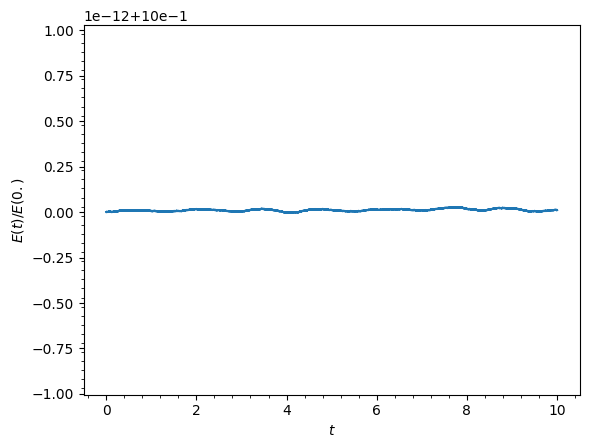

In [28]:
o.plotEnorm();

## Accessing raw orbital data

Evaluate orbital quantities at any time, or get the full array.

In [31]:
# At specific time
print("R(t=5):", o.R(5.0))
print("phi(t=5):", o.phi(5.0))

# Full orbit array: shape (ntimes, ndim)
orbit_array = o.getOrbit()
print("Full orbit shape:", orbit_array.shape)

R(t=5): 1.0248822021703112
phi(t=5): -1.355027550131503
Full orbit shape: (10000, 6)


Sky coordinates and many other quantities are also available as attributes (see the [API documentation](../../reference/orbit.rst) for a complete list).

In [33]:
# Sky coordinates at specific time (requires ro/vo)
print("RA(t=5):", o_sky.ra(5.0))
print("Dec(t=5):", o_sky.dec(5.0))

RA(t=5): 204.3700933860206
Dec(t=5): -64.02927160795767


## Creating a new orbit from evaluated position

Calling an orbit as a function returns a new Orbit at that time.

In [34]:
o_at_5 = o(5.0)
print("New orbit at t=5:", o_at_5)
print("R:", o_at_5.R())

New orbit at t=5: <galpy.orbit.Orbits.Orbit object at 0x7c41dfd50aa0>
R: 1.0248822021703112


## Non-inertial frames

The default assumption in galpy is that the frame that an orbit is integrated in is an inertial one. However, galpy also supports orbit integration in non-inertial frames that are rotating or whose center is accelerating (or a combination of the two). When a frame is not an inertial frame, fictitious forces such as the centrifugal and Coriolis forces need to be taken into account. galpy implements all of the necessary forces as part of the [NonInertialFrameForce](../../reference/potentialnoninertialframe.rst#noninertialframe-potential) class. objects of this class are instantiated with arbitrary three-dimensional rotation frequencies (and their time derivative) and/or arbitrary three-dimensional acceleration of the origin. The class documentation linked to above provides full mathematical details on the rotation and acceleration of the non-inertial frame.

We can then, for example, integrate the orbit of the Sun in the LSR frame, that is, the frame that is corotating with that of the circular orbit at the location of the Sun. To do this for ``MWPotential2014``, do

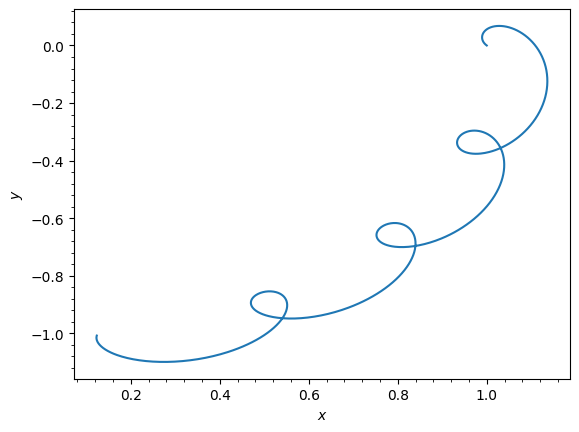

In [39]:
from galpy.potential import MWPotential2014, NonInertialFrameForce

nip = NonInertialFrameForce(Omega=1.0)  # LSR has Omega=1 in natural units
o = Orbit()  # Orbit() is the orbit of the Sun in the inertial frame
o.turn_physical_off()  # To use internal units
o = Orbit(
    [o.R(), o.vR(), o.vT() - 1.0, o.z(), o.vz(), o.phi()]
)  # Convert to the LSR frame
ts = numpy.linspace(0.0, 20.0, 1001)
o.integrate(ts, MWPotential2014 + nip)
o.plot(d1="x", d2="y");

we can compare this to integrating the orbit in the inertial frame and displaying it in the non-inertial LSR frame as follows:

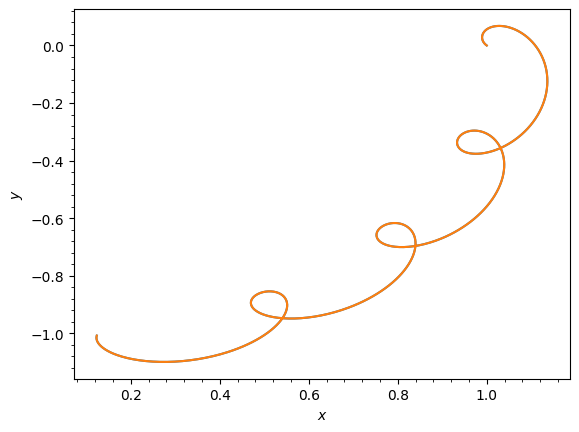

In [40]:
o.plot(d1="x", d2="y")  # Repeat plot from above
o = Orbit()  # Orbit() is the orbit of the Sun in the inertial frame
o.turn_physical_off()  # To use internal units
o.integrate(ts, MWPotential2014)
o.plot(
    d1="R*cos(phi-t)", d2="R*sin(phi-t)", overplot=True
);  # Omega = 1, so Omega t = t

We can also do all of the above in physical units, in which case the first example above becomes

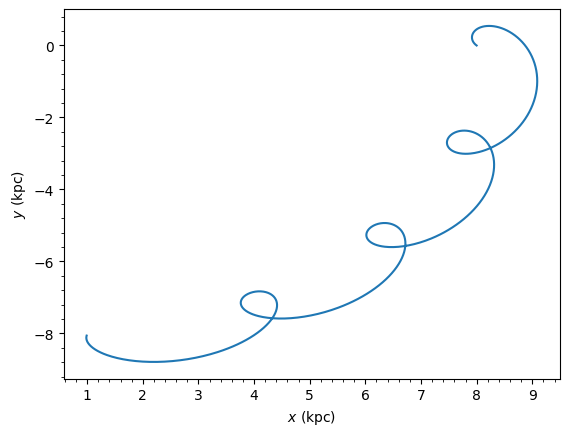

In [42]:
from galpy.potential import MWPotential2014, NonInertialFrameForce
from astropy import units

nip = NonInertialFrameForce(Omega=220.0 / 8.0 * units.km / units.s / units.kpc)
o = Orbit()  # Orbit() is the orbit of the Sun in the inertial frame
o = Orbit(
    [
        o.R(quantity=True),
        o.vR(quantity=True),
        o.vT(quantity=True) - 220.0 * units.km / units.s,
        o.z(quantity=True),
        o.vz(quantity=True),
        o.phi(quantity=True),
    ]
)  # Convert to the LSR frame
ts = numpy.linspace(0.0, 20.0, 1001)
o.integrate(ts, MWPotential2014 + nip)
o.plot(d1="x", d2="y");

We can also provide the ``Omega=`` frequency as an arbitrary function of time. In this case, the frequency must be returned in internal units and the input time of this function must be in internal units as well (use the routines in [galpy.util.conversion](../../reference/conversion.rst#bovyconversion) for converting from physical to internal units; you need to divide by these to go from physical to internal). For the example above, this would amount to setting

In [43]:
nip = NonInertialFrameForce(Omega=lambda t: 1.0, Omegadot=lambda t: 0.0)

Note that when we supply Omega as a function, it is necessary to specify its time derivative as well as Omegadot (all again in internal units).

We give an example of having the origin of the non-inertial frame accelerate in the [orbit examples](examples.ipynb) tutorial.

## Surfaces of section

galpy can compute surfaces of section (SOS) for 2D and 3D orbits using a special
integration method that exactly determines intersections between orbits and a surface.
The implemented method follows [Hunter et al. (1998)](https://ui.adsabs.harvard.edu/abs/1998NYASA.867...61H/abstract) in re-writing the integration in terms of an independent angular variable 𝜓 that is equal to a multiple of 2⁢𝜋 at intersections of the orbit with a surface of section (see Section 13.1 of [galaxiesbook.org](https://galaxiesbook.org/chapters/III-02.-Orbits-in-Triaxial-Mass-Distributions-and-Surfaces-of-Section_1-Surfaces-of-section.html#while-the-method-we-have-used-so)).

Supported surfaces:
- **3D orbits:** $z=0, v_z>0$ surface
- **2D orbits:** $x=0, v_x>0$ or $y=0, v_y>0$ surfaces

Surfaces of section are most useful for static, axisymmetric potentials (3D) or
static, non-axisymmetric potentials (2D).

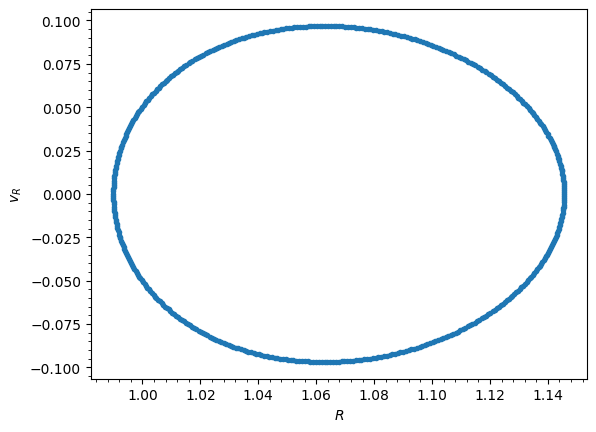

In [22]:
# Surface of section for the Sun's orbit in MWPotential2014
o_sun = Orbit()
o_sun.turn_physical_off()
o_sun.plotSOS(MWPotential2014);

You can also retrieve the SOS crossing values directly using `o.SOS()`:

In [23]:
# Get the SOS values directly
Rs, vRs = o_sun.SOS(MWPotential2014)
print("Number of SOS crossings:", len(Rs))

Number of SOS crossings: 500


For 2D orbits, we can compute surfaces of section in the `x` or `y` planes:

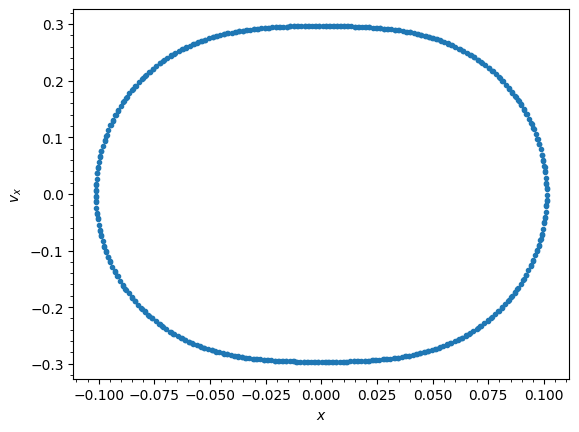

In [24]:
# 2D example: box orbit in a non-axisymmetric cored logarithmic potential
lp_2d = LogarithmicHaloPotential(normalize=True, b=0.9, core=0.2)
orb_2d = Orbit([0.1, 0.0, lp_2d.vcirc(0.1, phi=0.0), numpy.pi / 2.0])
orb_2d.plotSOS(lp_2d, surface="y");

Surfaces of section can also be computed for Orbit instances that contain multiple orbits, e.g., for the following two orbits defined to have the same energy and angular momentum:

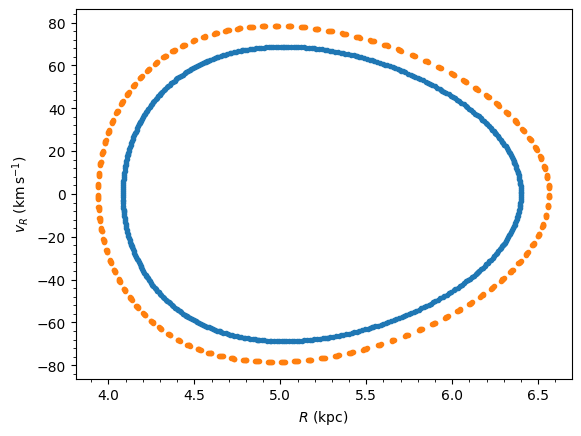

In [45]:
from galpy.potential import evaluatePotentials


def orbit_RvRELz(R, vR, E, Lz, z_init=0.0, pot=None):
    """Returns Orbit at (R,vR,phi=0,z=z_init) with given (E,Lz)"""
    return Orbit(
        [
            R,
            vR,
            Lz / R,
            z_init,
            numpy.sqrt(
                2.0
                * (
                    E
                    - evaluatePotentials(pot, R, z_init)
                    - (Lz / R) ** 2.0 / 2.0
                    - vR**2.0 / 2
                )
            ),
            0.0,
        ],
        ro=8.0,
        vo=220.0,
    )


R, E, Lz = 0.8, -1.25, 0.6
twoorb = Orbit(
    [
        orbit_RvRELz(R, 0.0, E, Lz, pot=MWPotential2014),
        orbit_RvRELz(R, 0.1, E, Lz, pot=MWPotential2014, z_init=0.1),
    ]
)
twoorb.plotSOS(MWPotential2014);

For some force fields, the reparameterization of the orbit in terms of $\psi$ does not work, because the angle $\psi$ does not increase monotonically with time. This is notably the case for many orbits integrated in a non-inertial frame (e.g., bar orbits in the bar’s rotating frame). In these cases, you can use a brute-force approach to determining the surface of section implemented in ``Orbit.bruteSOS`` and ``Orbit.plotBruteSOS``, which work similarly to the ``Orbit.SOS`` and ``Orbit.plotSOS`` methods discussed above, but simply look for surface crossings using a regular orbit integration. In this case, you have to specify how long to integrate the orbit for and you can, therefore, not directly control the number of crossings that you will get.

<div class="alert alert-warning">

**Warning**

Computing the surface of section leaves the Orbit instance in a state where its internally-stored integrated orbit is that computed during the surface-of-section integration (any previously integrated orbit is overwritten). However, the orbit is only output at intersections with the surface of section. Furthermore, with an Orbit like that of the Sun above whose initial condition is not in the surface of section, the first point along this orbit is not the initial condition, but the first surface-of-section crossing instead. This is because for orbits like this, internally galpy first integrates to the first crossing and then re-starts the integration to obtain many subsequent crossings to create the surface of section.

</div>

## Integration of the phase-space volume

galpy supports the integration of the phase-space volume through the method
`integrate_dxdv`. This is currently only implemented for two-dimensional orbits
(planar orbits). This can be used to, for example, explicitly verify Liouville's
theorem (that phase-space volume is conserved along the orbit). See the
`integrate_dxdv` API documentation for details.

## Fast orbit integration and available integrators

For fast integration of many orbits, galpy provides fast C integrators accessed via the `method=` keyword.

**C integrators (recommended for speed):**
- `rk4_c`, `rk6_c`: Runge-Kutta methods
- `dopr54_c`, `dop853_c`: Dormand-Prince methods
- `ias15_c`: IAS15 integrator (Rein & Spiegel 2014), adaptive timestepping for high precision

**Symplectic C integrators:**
- `leapfrog_c`, `symplec4_c`, `symplec6_c`

**Pure Python integrators:**
- `leapfrog`, `odeint`, `dop853`

For most applications, `symplec4_c` or `dop853_c` are recommended. The `ias15_c` integrator from [Rein & Spiegel 2014](https://ui.adsabs.harvard.edu/abs/2015MNRAS.446.1424R/abstract) is a good choice when extreme high-precision is required, but it is slow compared to other C integrators. The higher order symplectic integrators are described in [Yoshida (1993)](http://adsabs.harvard.edu/abs/1993CeMDA..56...27Y).

In [25]:
# Check if a potential has a C implementation
from galpy.potential import MiyamotoNagaiPotential as MNP

mp_test = MNP(a=0.5, b=0.0375, amp=1.0, normalize=1.0)
print("MiyamotoNagaiPotential has C:", mp_test.hasC)

# Integrate using the fast dop853_c method
o_fast = Orbit([1.0, 0.1, 1.1, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 100.0, 10001)
o_fast.integrate(ts, MWPotential2014, method="dop853_c")
print("Integration with dop853_c complete.")

MiyamotoNagaiPotential has C: True
Integration with dop853_c complete.


If no C implementation of the potential (or one of its components) is available, galpy will automatically fall back to using a pure Python integrator. 